device: cuda


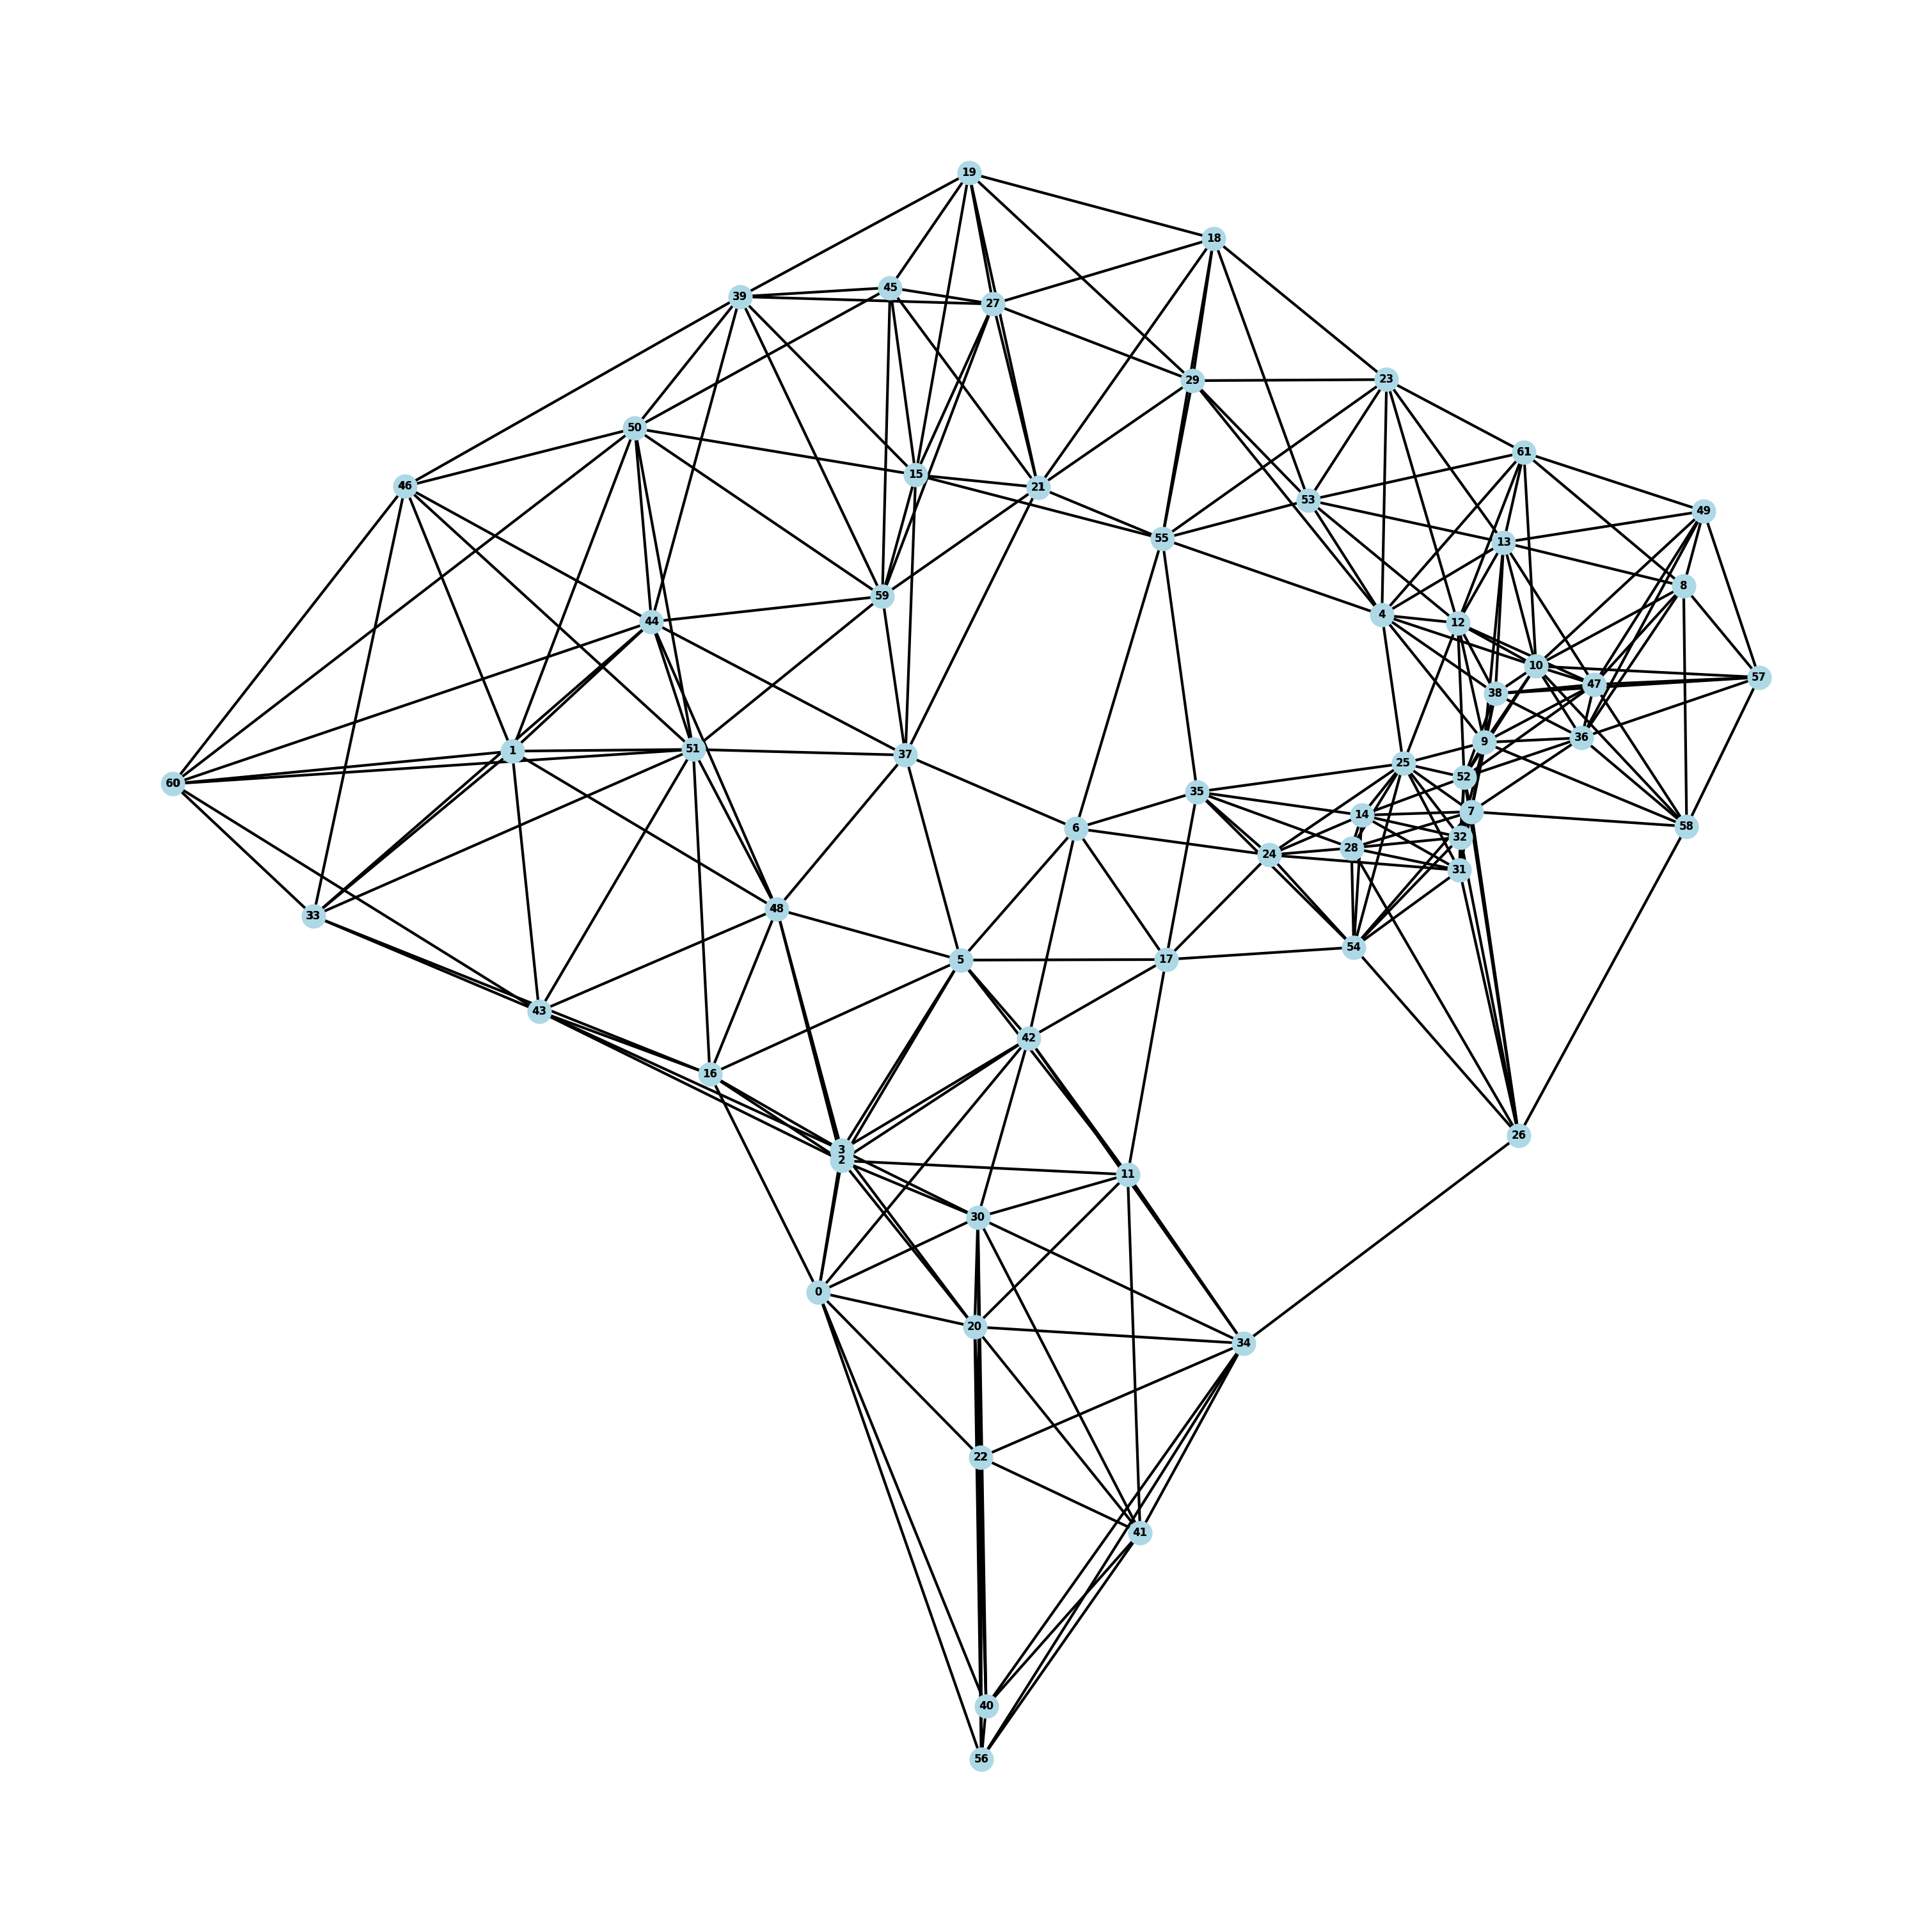

In [ ]:
import os
import copy
import json
import time
from pathlib import Path
import yaml
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append("../src")


from Models.model_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape

from Evaluation.comparison_plots import save_error_plots, create_next_experiment_folder, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, grafo_distancias

from Training.Training_Routines import eval_with_loader, train_batched_only

from Dataset_Utils import tensor_data


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "2014-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2025-12-01"
    end_date = "2025-12-31"


criterion_km = 115
batch_size = 64
num_workers = 0

catalog_dir = Path(r"C:\Climate Change Project\Datasets\Dados INMET")
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

N = len(estacoes_RS)


edge_index_knn, pos_knn = knn_topology(estacoes_RS, k=7)

edge_index_distance, pos_dis = grafo_distancias(estacoes_RS, criterion_km)

plot_graph(N, edge_index_knn, pos_knn)

In [ ]:
# Data loading and feature construction

#TENSOR X COM TODAS COVARIAVEIS E DADOS NO FORMATO [T,N,F]
# X[...,0]    : DADOS DE PRECIPITAÇÃO
# X[...,1]    : VARIAVEL PÉRIODICA COM PERIODO 365
# X[...,2:8]  : DADOS DE TEMPERATURA
# X[...,9:15] : DADOS DE VELOCIDADE VERTICAL
# X[...,16,31]: DADOS DE WIND


rea_tp = xr.open_dataset(r"C:\Climate Change Project\Datasets\.nc files\era5_precipitation_80-26.nc")
rea_vv = xr.open_dataset(r"C:\Climate Change Project\Utils\vertical_velocity_data\era5_vv_06-25.nc").sel(time=slice(start_date, None))
rea_temp = xr.open_dataset(r"C:\Climate Change Project\Utils\temperature_data\temp_05-25.nc")
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc")



vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_dataset = daily_temp_features(rea_temp)
wind_daily = daily_wind_uv_features(rea_wind, u_var='u', v_var='v', levels=(500, 850))

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1
#X = torch.zeros((T, N, 32), dtype=torch.float32)

#X_tp = 1000.0 * torch.tensor(
#    tensor_data(pd.to_datetime(start_date), pd.to_datetime(end_date), rea, estacoes_RS),
#    dtype=torch.float32, 
#).reshape(T, N, 1)

X_tp = tensor_data_precip(rea_tp, t1=start_date, t2=end_date, stations=estacoes_RS)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_dataset, stations=estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_dataset, estacoes_RS)

#X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
                           estacoes_RS,
                           start=start_date,
                           end=end_date,
                           u_var="u",
                           v_var="v"
                           ).reshape(X_tp.shape[0], X_tp.shape[1], -1)

X = torch.cat([X_tp, X_temp, X_vv, X_wind], dim=-1)

C:\Users\bruno\AppData\Local\Temp\ipykernel_16844\2463747732.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_tp = 1000.0 * torch.tensor(


In [ ]:
#CRIAÇÃO DE JANELAS DE TEMPO
eps = 1e-6
window_size = 30
horizon     = 5


Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)

X_train, y_train, X_val, y_val, X_test, y_test = train_split(Xs, ys)


target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test, target_mean, target_std)



# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)

normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)

In [19]:
# Train/val split and DataLoaders
batch_size = 64
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

pin_memory = (device == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

train batches: 48 val batches: 14 test batches: 7


In [20]:
#MODEL
edge_index, edge_weight = grafo_distancias(stations=estacoes_RS, criterion=criterion_km)
edge_index = edge_index.to(device)

class GLSTMCellBatch(nn.Module):
    def __init__(self, N, input_size, hidden_size, edge_index, edge_weight=None, learn_adj=True):
        super().__init__()
        self.edge_index = edge_index
        self.learn_adj = learn_adj
        
        
        if edge_weight is None:
            self.edge_weight = None if not learn_adj else torch.ones(edge_index.shape[1], device=edge_index.device)
        else:
            self.edge_weight = edge_weight.to(edge_index.device) if torch.is_tensor(edge_weight) else torch.tensor(edge_weight, device=edge_index.device)

        A_init = adjacency_matrix(N, edge_index, self.edge_weight)+torch.eye(N).to(edge_index.device)
        if learn_adj:
            self.A = nn.Parameter(A_init)
        else:
            self.register_buffer("A", A_init)
            
        
        self.W_i = nn.Linear(input_size, hidden_size).to(device)
        self.W_f = nn.Linear(input_size, hidden_size).to(device)
        self.W_o = nn.Linear(input_size, hidden_size).to(device)
        self.W_u = nn.Linear(input_size, hidden_size).to(device)

        self.U_i = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_f = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_o = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_u = nn.Linear(hidden_size, hidden_size).to(device)

    def forward(self, X, H_prev, C_prev):
        # X: [B, N, F], H/C: [B, H, N]
        T, N, F = X.shape
        if self.learn_adj:
            
            #A_eff = self.A
            #self.A = nn.Parameter(self.A+self.A.T)
            #A_raw = self.A
            #A_pos = F.softplus(A_raw)
            #A_eff = A_pos / (A_pos.sum(dim=1, keepdim=True)+1e-6)
  
                    
            H_graph = torch.einsum("bhm,mn->bhn", H_prev, self.A).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, self.A).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
        else:

            H_graph = torch.einsum("bhm,mn->bhn", H_prev, self.A).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, self.A).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
            
       
        Xp = X.to(device)

        I = torch.sigmoid(self.W_i(Xp) + self.U_i(Hg)).permute(0, 2, 1)
        Fg = torch.sigmoid(self.W_f(Xp) + self.U_f(Hp)).permute(0, 2, 1)
        O = torch.sigmoid(self.W_o(Xp) + self.U_o(Hg)).permute(0, 2, 1)
        U = torch.tanh(self.W_u(Xp) + self.U_u(Hg)).permute(0, 2, 1)

        C_t = I * U + Fg * C_graph
        H_t = O * torch.tanh(C_t)
        return C_t, H_t


class GLSTMBatch(nn.Module):
    def __init__(self, N, edge_index, in_channels, hidden_size, out_channels=horizon, lstm_layers=1, learn_adj=True):
        super().__init__()
        self.N = N
        self.lstm_layers = lstm_layers
        self.hidden_size = hidden_size
        self.window = out_channels
        
        #LSTM blocks
        self.cell_0 = GLSTMCellBatch(N, in_channels, hidden_size, edge_index, learn_adj=learn_adj)
        self.cells = nn.ModuleList([GLSTMCellBatch(N=N, input_size=hidden_size, hidden_size=hidden_size,edge_index=edge_index, learn_adj=learn_adj) for _ in range(self.lstm_layers-1)])
        
        #fully connected layer
        self.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, out_channels)
        ).to(device)
        

    def forward(self, x_seq):
        # x_seq: [B, T, N, F]
        
        B, T, N, _ = x_seq.shape

        H = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
        C = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
        
        
        H_layers = torch.zeros((B, T, self.N, self.hidden_size), device=x_seq.device, dtype=x_seq.dtype)
        
        
        for t in range(T):
            C, H = self.cell_0(x_seq[:,t], H, C)
            H_layers[:,t] = H.permute(0,2,1)
        

        for j in range(self.lstm_layers-1):
                H = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
                C = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
                for t in range(T):

                    C, H = self.cells[j](H_layers[:,t], H, C)
                    H_layers[:,t] = H.permute(0,2,1)

        out = H_layers[:,-1].to(device)

        return self.fc(out).permute(0, 2, 1)   # [B, OUT, N]

In [22]:
#funções de plots necessárias

def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[:, station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[:, station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    n_in = model.cell.W_i.in_features
    seq_len = train_period - 1

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.sack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real

In [24]:
def combined_loss(y_pred, y_true,alpha=0.5):
    mse = nn.MSELoss()
    mae = nn.L1Loss()
    return alpha*mse(y_pred, y_true)+(1-alpha)*mae(y_pred, y_true)


def weighted_mse_loss(
    y_pred,
    y_true,
    extreme_quantile=0.9,
    extreme_weight=10.0,
    is_log=False,
    eps=1e-6
):
    """
    Weighted MSE loss that emphasizes extreme rainfall, compatible with both
    log-transformed and raw targets.

    Args:
        y_pred: torch.Tensor, model predictions
        y_true: torch.Tensor, true values
        extreme_quantile: float, quantile to define "extreme rainfall" (default 0.9)
        extreme_weight: float, weight multiplier for extreme rainfall (default 5.0)
        is_log: bool, whether y_true (and y_pred) are log-transformed (default True)
        eps: small number to prevent log(0)
    """
    # Compute threshold in original scale
    if is_log:
        y_true_orig = torch.expm1(y_true)
        y_pred_orig = torch.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    threshold = torch.quantile(y_true_orig, extreme_quantile)

    # Create weights: extreme rainfall gets high weight
    weights = torch.ones_like(y_true)
    weights[y_true_orig > threshold] = extreme_weight

    # Weighted MSE (compute on original scale if is_log)
    if is_log:
        # compute loss in log space (optional: can use pred vs true in log)
        loss = torch.mean(weights * (y_pred - y_true) ** 2)
    else:
        loss = torch.mean(weights * (y_pred - y_true) ** 2)

    return loss

In [31]:
edge_index = edge_index_knn.to(device)
loss_fn = nn.MSELoss()

for lr in [1e-4]:
    for hidden_dim in [128]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=False)

        model.apply(reset_weights)        
        window_folder = f"C:\\Experiments\\multi_step_pred_model_11_03\_WINDOW_{window_size}_HORIZON_{horizon}"

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=350, lr=lr, weight_decay=5e-4, patience=35, criterion=loss_fn,run_dir=exp_path+f"\\BATCH_TEST_{j}"
            )

<>:12: SyntaxWarning: invalid escape sequence '\_'
<>:12: SyntaxWarning: invalid escape sequence '\_'
C:\Users\bruno\AppData\Local\Temp\ipykernel_16844\4219250766.py:12: SyntaxWarning: invalid escape sequence '\_'
  window_folder = f"C:\\Experiments\\multi_step_pred_model_11_03\_WINDOW_{window_size}_HORIZON_{horizon}"


========================HIDDEN_DIM: 128=============================
========================ITERATION 0=============================
train_batched_only: use_amp=False
epoch=1/350train_loss=1.075809e+00/val_loss=1.106147e+00/train_mae=8.637430e-01/val_mae=8.455301e-01/val_mape=1.163782e+02/val_r2=-5.270969e-02
epoch=2/350train_loss=1.048901e+00/val_loss=1.088077e+00/train_mae=8.453023e-01/val_mae=8.556436e-01/val_mape=1.150063e+02/val_r2=-3.836449e-02
epoch=3/350train_loss=1.031358e+00/val_loss=1.086447e+00/train_mae=8.369042e-01/val_mae=8.480090e-01/val_mape=1.136129e+02/val_r2=-3.596745e-02
epoch=4/350train_loss=1.025751e+00/val_loss=1.078472e+00/train_mae=8.388582e-01/val_mae=8.444582e-01/val_mape=1.120519e+02/val_r2=-2.838804e-02
epoch=5/350train_loss=1.018508e+00/val_loss=1.071654e+00/train_mae=8.400592e-01/val_mae=8.470792e-01/val_mape=1.125747e+02/val_r2=-2.367000e-02
epoch=6/350train_loss=1.010680e+00/val_loss=1.073458e+00/train_mae=8.327300e-01/val_mae=8.354892e-01/val_mape=1.

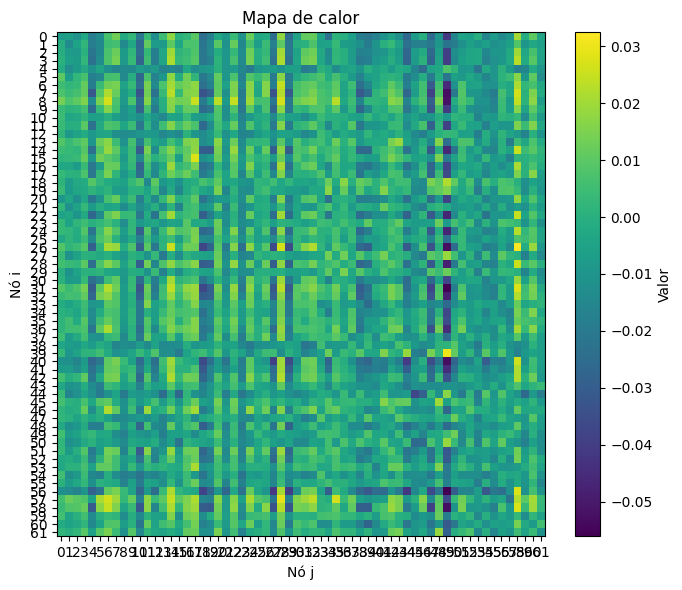

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [52]:
def plot_heatmap_nn(M, title="Mapa de calor", cmap="viridis", vmin=None, vmax=None):
    """
    Plota mapa de calor de uma matriz NxN.
    Aceita numpy array, lista de listas ou tensor do PyTorch.
    Retorna (fig, ax).
    """
    if hasattr(M, "detach"):  # torch.Tensor
        M = M.detach().cpu().numpy()
    else:
        M = np.asarray(M)

    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError(f"A matriz deve ser NxN. Recebido shape={M.shape}")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(M, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Valor")

    ax.set_title(title)
    ax.set_xlabel("Nó j")
    ax.set_ylabel("Nó i")
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))

    plt.tight_layout()
    plt.show()
    return fig, ax


plot_heatmap_nn(model.cell_0.A)

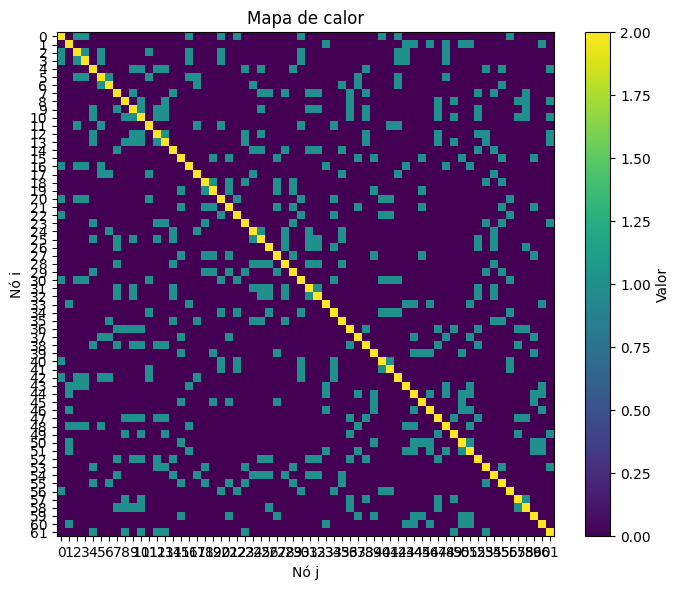

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [51]:
pred = model(X_test.to(device)).detach().cpu()
pred_denormalized = torch.expm1(pred*target_std+target_mean)
y_test_denormalized = torch.expm1(y_test*target_std+target_mean)

tensor(-0.4371)


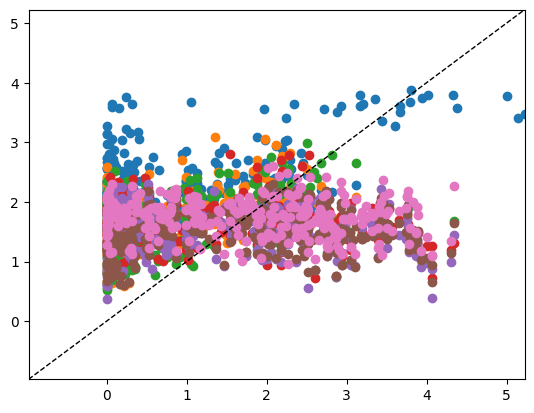

In [33]:
lims = [
    min(y_test_denormalized.min(), pred_denormalized.min()),
    max(y_test_denormalized.max(), pred_denormalized.max())
]


print(safe_r2(y_test_denormalized, pred_denormalized))

plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
for time_test in range(50,57):
    plt.scatter(y_test_denormalized[time_test].reshape(-1,1), pred_denormalized[time_test].reshape(-1,1))

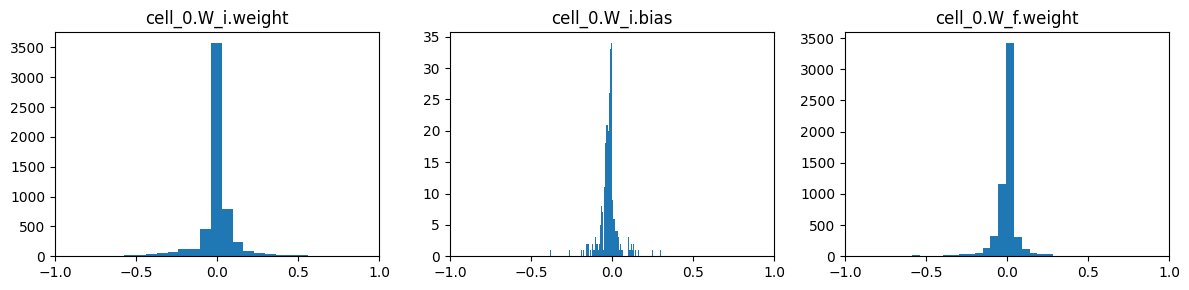

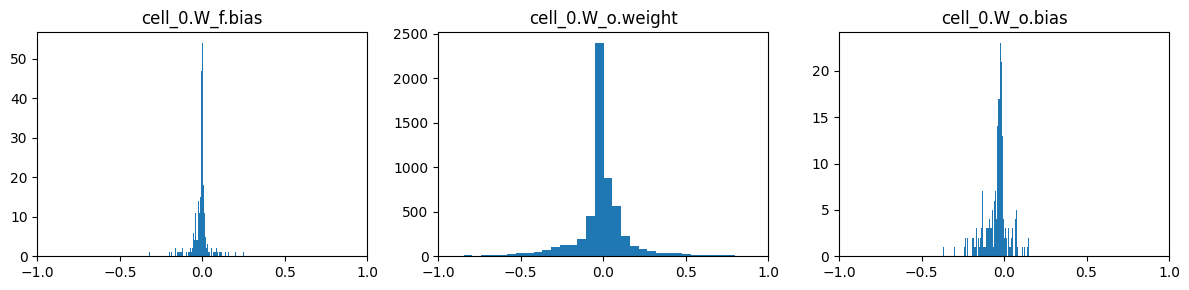

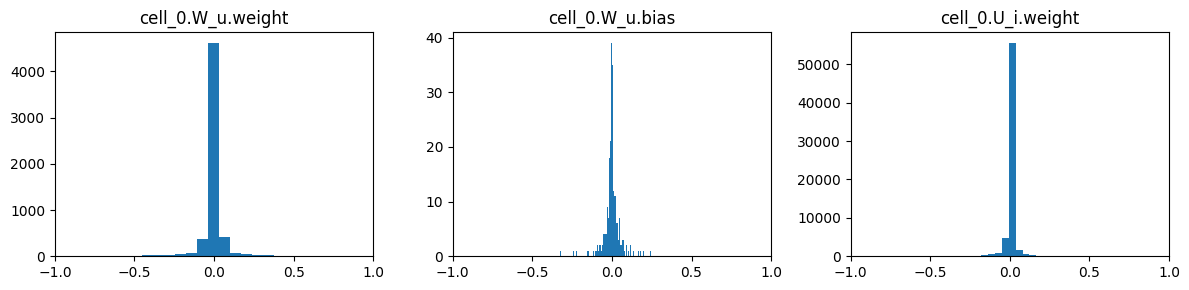

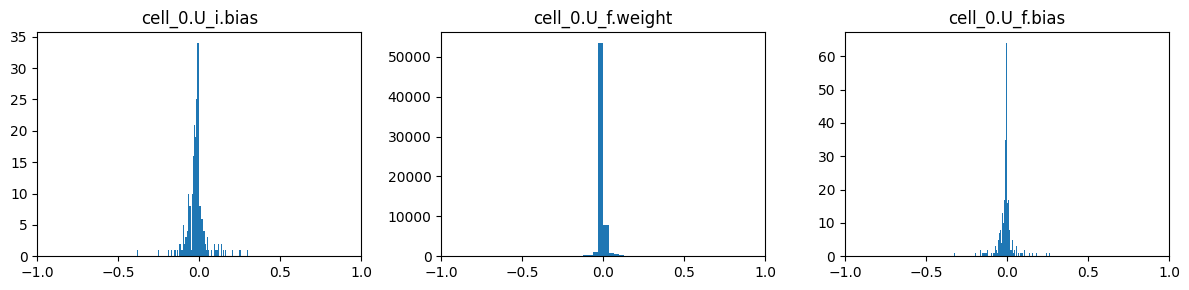

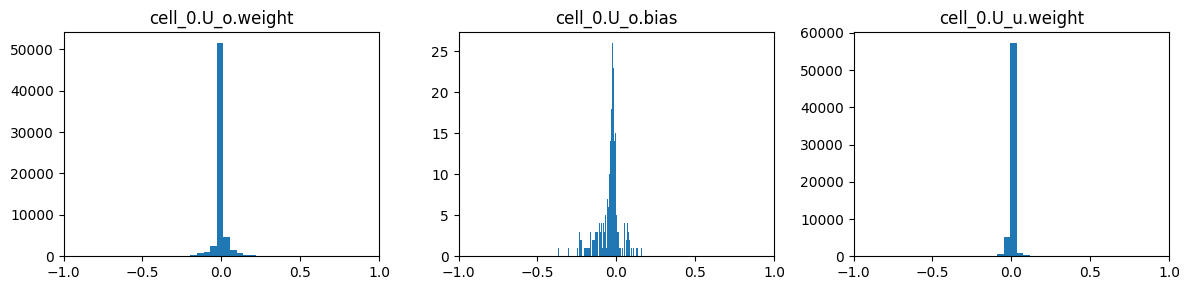

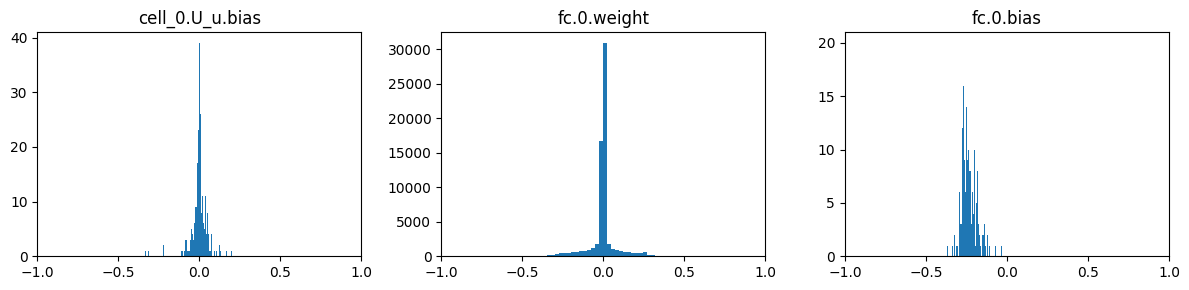

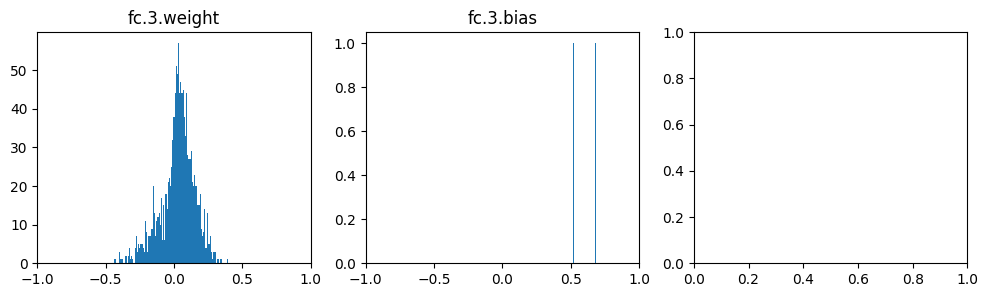

In [21]:
model_weights_hist(model)